In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Domain and sampling
# -----------------------------
vmin, vmax = -1.0, 1.0                     # domain limits for x,y,z
vs = 0.4                                   # grid step
n_points = int((vmax - vmin) / vs) + 1     # include endpoint

x = np.linspace(vmin, vmax, n_points)
y = np.linspace(vmin, vmax, n_points)
z = np.linspace(vmin, vmax, n_points)

dx = x[1] - x[0]
dy = y[1] - y[0]
dz = z[1] - z[0]

# 3D grid
X, Y, Z = np.meshgrid(x, y, z, indexing="xy")

# -----------------------------
# Define vector field f = (fx, fy, fz)
# Choose ONE example (uncomment to switch)
# -----------------------------

# Example 1:
# fx = X - Z
# fy = X * Z
# fz = Y**2
# title_str = "vec f = (x - z, x*z, y^2)"

# Example 2:
# fx = 5*X**2
# fy = 3*Y**2
# fz = 0*Z
# title_str = "vec f = (5x^2, 3y^2, 0)"

# Example 3 (default):
fx = X
fy = Y
fz = Z
title_str = "vec f = (x, y, z)"

# Example 4:
# fx = (X**2)*Y
# fy = (Y**2)*Z
# fz = (Z**2)*X
# title_str = "vec f = (x^2*y, y^2*z, z^2*x)"

# -----------------------------
# Divergence: div f = ∂fx/∂x + ∂fy/∂y + ∂fz/∂z
# np.gradient over array order [y, x, z] returns (d/dy, d/dx, d/dz)
# -----------------------------
_, dfx_dx, _ = np.gradient(fx, dy, dx, dz)  # ∂fx/∂x  (second return)
dfy_dy, _, _ = np.gradient(fy, dy, dx, dz)  # ∂fy/∂y  (first return)
_, _, dfz_dz = np.gradient(fz, dy, dx, dz)  # ∂fz/∂z  (third return)

div = dfx_dx + dfy_dy + dfz_dz

# -----------------------------
# Choose a z-slice to visualize
# -----------------------------
m = n_points // 2 + 1
m = min(m, n_points - 1)
z_m = z[m]


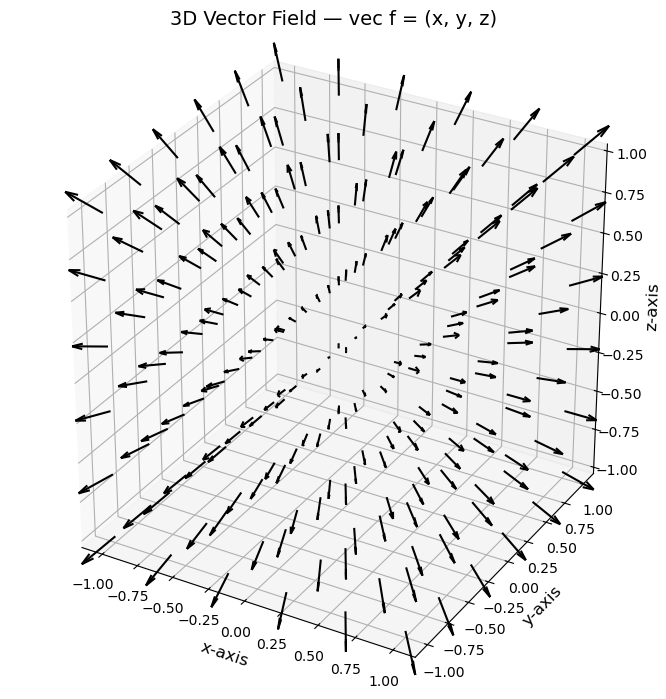

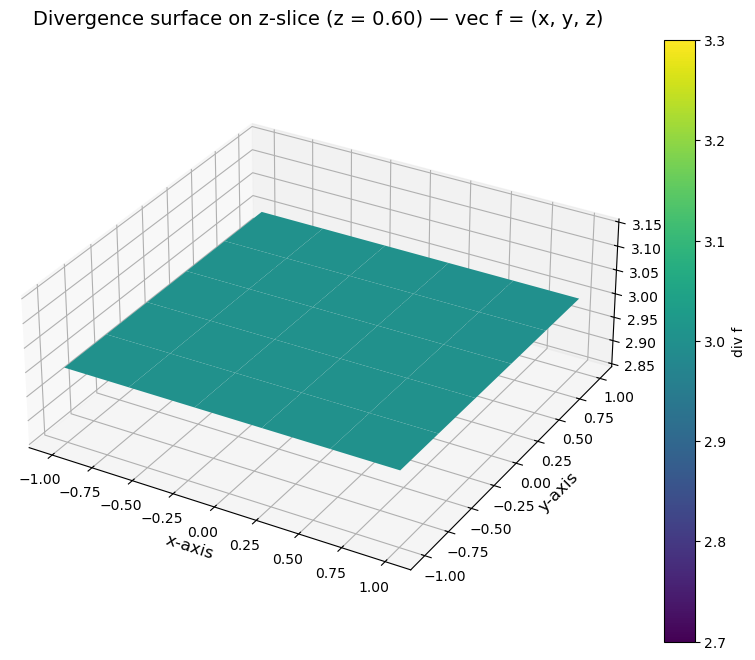

In [11]:
# -----------------------------
# 3D quiver of the vector field
# -----------------------------
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

# Downsample for clarity if the grid is dense (optional)
step = 1
ax.quiver(
    X[::step, ::step, ::step],
    Y[::step, ::step, ::step],
    Z[::step, ::step, ::step],
    fx[::step, ::step, ::step],
    fy[::step, ::step, ::step],
    fz[::step, ::step, ::step],
    length=0.15, normalize=False, color="black"
)

ax.set_xlabel('x-axis', fontsize=12)
ax.set_ylabel('y-axis', fontsize=12)
ax.set_zlabel('z-axis', fontsize=12)
ax.set_title(f'3D Vector Field — {title_str}', fontsize=14)
ax.set_box_aspect((1, 1, 1))  # equal aspect in 3D
plt.tight_layout()
plt.show()

# -----------------------------
# Divergence on a fixed z-slice: surface + colorbar
# -----------------------------
Xs, Ys = X[:, :, m], Y[:, :, m]
Divs   = div[:, :, m]

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    Xs, Ys, Divs,
    cmap='viridis', linewidth=0, antialiased=True, shade=True
)
fig.colorbar(surf, label='div f', shrink=0.9)

ax.set_xlabel('x-axis', fontsize=12)
ax.set_ylabel('y-axis', fontsize=12)
ax.set_zlabel('div f', fontsize=12)
ax.set_title(f'Divergence surface on z-slice (z = {z_m:.2f}) — {title_str}', fontsize=14)

# Proportional appearance (x:y:z box ratio); z can be adjusted as needed
ax.set_box_aspect((1, 1, 0.4))

plt.tight_layout()
plt.show()